In [1]:
import json
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from astropy.io import fits
from astropy.io import fits
from astropy.table import Table
import json
import sys

In [2]:
sys.path.append(str(Path().resolve() / 'py_modules')) 

from rebin_utils import downsample

#  Region and obs data

In [3]:
line        = r'[N II] $\lambda$6584'
lambda_rest = 6583.45
line_id     = 'N'

In [4]:
# Downsample
bins        = 0

# Data region
region     = 'NGC 2070'
name_reg   = '30 Doradus'
reg_id     = 'Dor'
inst       = 'MUSE'
inst_id    = 'MUSE'
type_obj   = 'H II region'
dist       = 50000 # Distance [parsecs]

# Data from observations
pix        = 0.2   # Instrument resolution [arcsec/pix]
s0_        = 0.9    # proposed seeing

# Parsec convertion proposed and proposed seeing
pc         = dist*(2*np.pi) / (360 * 60 * 60)
s0         = (s0_*pc)


In [5]:
# Observational file
name_file    =  inst_id + '-' + reg_id + '-' + line_id 

# Since we are working with matrix data binning can be applied so we add that to the name
name_id      =  inst_id + '-' + reg_id + '-' + line_id + '-' + 'bin' + str(bins)

# Print
print(name_file)
print(name_id)

MUSE-Dor-N
MUSE-Dor-N-bin0


# Loading data

In [6]:
_data = json.load(open('observations/'+ name_file + '-m.json'))
sb    = np.array(_data['sb'])
vv    = np.array(_data['vv'])
ss    = np.array(_data['ss'])

In [7]:
## Replace spurious values in the arrays
m = ~np.isfinite(sb*vv*ss) | (sb < 0.0)
#m = m | (sb > 6e4) 
sb[m] = 0.0
vv[m] = np.nanmean(vv)
ss[m] = 0.0
sb   /= sb.max()

mu = vv.mean()
sigma = vv.std()
n = 3

good = (~m) & (sb > 1e-3) & (vv > (mu - n*sigma)) & (vv < (mu + n*sigma))

In [8]:
# mask for VIENTO pipeline
vv_m = np.where(good, vv, mu)     
sb_m = np.where(good, sb, 0)     
ss_m = np.where(good, ss, np.nanmean(ss))   

<>:11: SyntaxWarning: invalid escape sequence '\s'
<>:11: SyntaxWarning: invalid escape sequence '\s'
C:\Users\ZAINTEL2\AppData\Local\Temp\ipykernel_20464\3798436418.py:11: SyntaxWarning: invalid escape sequence '\s'
  cbar.set_label("$\sigma$ (-)", rotation=270, labelpad=15)


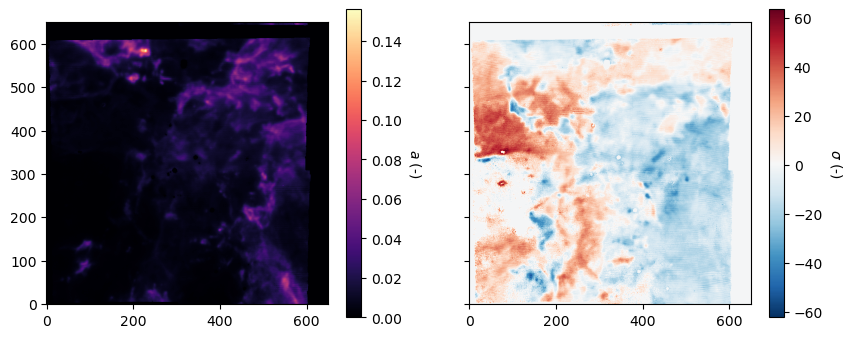

In [9]:
fig, (axx, ax) = plt.subplots(
    1,
    2,
    sharey=True,
    figsize=(10, 4),
)
imshow_kwds = dict(origin="lower", cmap="RdBu_r")
imshow_kwds2 = dict(origin="lower", cmap="magma")
im = ax.imshow((vv_m-np.nanmean(vv)), **imshow_kwds)
cbar = fig.colorbar(im, ax=[ax])
cbar.set_label("$\sigma$ (-)", rotation=270, labelpad=15)
im = axx.imshow(sb_m, **imshow_kwds2)
cbar = fig.colorbar(im, ax=[axx])
cbar.set_label("$a$ (-)", rotation=270, labelpad=15)

In [10]:
trim = (slice(10, 600), slice(30, 590))
trim

(slice(10, 600, None), slice(30, 590, None))

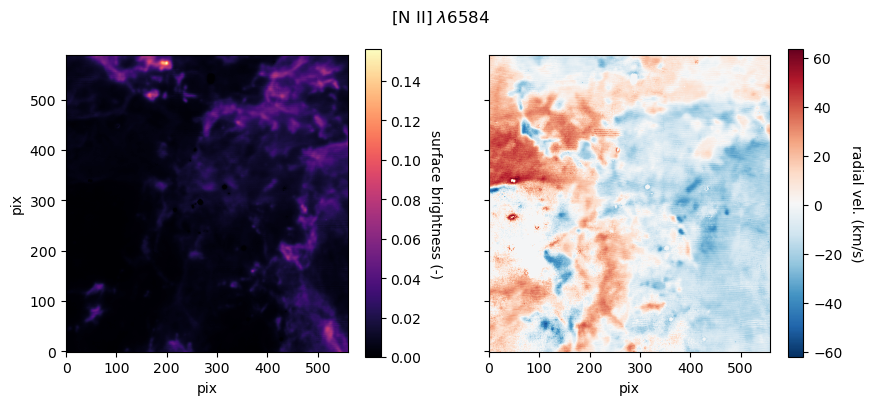

In [11]:
fig, (axx, ax) = plt.subplots(
    1,
    2,
    sharey=True,
    figsize=(10, 4),
)
imshow_kwds = dict(origin="lower", cmap="RdBu_r")
imshow_kwds2 = dict(origin="lower", cmap="magma")

im = ax.imshow((vv_m-np.nanmean(vv_m))[trim], **imshow_kwds)
cbar = fig.colorbar(im, ax=[ax])
cbar.set_label("radial vel. (km/s)", rotation=270, labelpad=15)

im = axx.imshow(sb_m[trim], **imshow_kwds2)
cbar = fig.colorbar(im, ax=[axx])
cbar.set_label("surface brightness (-)", rotation=270, labelpad=15)
ax.set_xlabel('pix')
axx.set_xlabel('pix')
axx.set_ylabel('pix')

fig.suptitle(line)

# Nice plot
plt.savefig('Imgs/' + name_id + '.jpg', bbox_inches='tight')

In [12]:
N = np.sqrt(vv_m[trim].shape[0] * vv_m[trim].shape[1]) * pix * pc
N

27.867299564396152

In [13]:
sig = np.nanstd(vv_m[trim])
sig

16.399432061921015

# Downsample

# Export

In [14]:
primary = fits.PrimaryHDU()
primary.header["FILE"]       = (name_file, "Fits file name")
primary.header["NAME_ID"]    = (name_id, "pipeline identifier")
primary.header["REG"]        = (region, "Region catalog name")
primary.header["NAME_REG"]   = (name_reg, "Region name")
primary.header["REG_ID"]     = (reg_id, "Region identifier")
primary.header["TYPE_OBJ"]   = (type_obj, "Type object")
primary.header["DIST"]       = (dist, "Distance in parsecs")
primary.header["INSTR"]      = (inst, "Instrument")
primary.header["LINE"]       = (line, "Emission line name")
primary.header["LINE_ID"]    = (line_id, "Emission line identifier")
primary.header["L_REST"]= (lambda_rest, "Emission line name")
primary.header["SIG"]        = (sig, "Standard deviation vel map")
primary.header["SIG2"]       = (sig**2, "Vel Variance map")
primary.header["S0"]         = (s0, "Atmospheric seeing")
primary.header["BOX_SIZE"]   = (N, "Observational box_size")
primary.header["PC"]         = (pc, "parsec convertion")
primary.header["PIX"]        = (pix, "Instrument pixel scale")
primary.header["BINSIZE"]    = (bins, "Spatial binning factor")
#hdr["noise"]     = (noise, "Instrumental noise")
#hdr["m3D"]       = (m3D, "k = 3 + m3D")
#hdr["ra"]        = (ra, "Artificial correlation length")
#primary.header["SEED1"]     = (randomseed_vv, "Random seed velocity")
#primary.header["SEED2"]     = (randomseed_sb, "Random seed surfavebrightness")
primary.header["AUTHOR"]     = ("J. Garcia-Vazquez", "File creator")

In [15]:
hdu_m0 = fits.ImageHDU(data=sb_m[trim],  name='MOM0')
hdu_m1 = fits.ImageHDU(data=vv_m[trim],  name='MOM1')
hdu_m2 = fits.ImageHDU(data=ss_m[trim],  name='MOM2')
hdu_mk = fits.ImageHDU(data=good[trim].astype(np.uint8) ,  name='MASK')

In [16]:
hdul = fits.HDUList([primary, hdu_m0, hdu_m1, hdu_m2, hdu_mk])
hdul.writeto('fits_ready/' + name_id + '.fits', overwrite=True)

In [17]:
with fits.open("fits_ready/" + name_id + ".fits") as hdul:
    hdul.info()

Filename: fits_ready/MUSE-Dor-N-bin0.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU      23   ()      
  1  MOM0          1 ImageHDU         8   (560, 590)   float64   
  2  MOM1          1 ImageHDU         8   (560, 590)   float64   
  3  MOM2          1 ImageHDU         8   (560, 590)   float64   
  4  MASK          1 ImageHDU         8   (560, 590)   uint8   
